# **Alura Challenge TelecomX Parte 2**

## 🛠️ **Preparación de los Datos**

### **Extracción del Archivo Tratado**

In [3]:
import pandas as pd

In [4]:
url = "https://raw.githubusercontent.com/epjuarez/alura-challenge-telecomx2/refs/heads/main/datos_tratados.csv"

df = pd.read_csv(url)

df.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,cuentas_diarias
0,0002-orfbo,0,female,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.6,593.30,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,59.9,542.40,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,73.9,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,98.0,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,83.9,267.40,2.796667


In [5]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7043 non-null   object 
 1   churn                      7043 non-null   int64  
 2   customer_gender            7043 non-null   object 
 3   customer_seniorcitizen     7043 non-null   int64  
 4   customer_partner           7043 non-null   int64  
 5   customer_dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_phoneservice         7043 non-null   int64  
 8   phone_multiplelines        7043 non-null   object 
 9   internet_internetservice   7043 non-null   object 
 10  internet_onlinesecurity    7043 non-null   object 
 11  internet_onlinebackup      7043 non-null   object 
 12  internet_deviceprotection  7043 non-null   object 
 13  internet_techsupport       7043 non-null   objec

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'cuentas_diarias'],
      dtype='object')

### **Eliminación de Columnas Irrelevantes**

In [6]:
df = df.drop(columns=['customerid'])

In [7]:
df.columns

Index(['churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'cuentas_diarias'],
      dtype='object')

### **Encoding**

In [8]:
df.dtypes

,0
churn,int64
customer_gender,object
customer_seniorcitizen,int64
customer_partner,int64
customer_dependents,int64
customer_tenure,int64
phone_phoneservice,int64
phone_multiplelines,object
internet_internetservice,object
internet_onlinesecurity,object


In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [10]:
df_encoded.head()

,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,cuentas_diarias,...,internet_techsupport_yes,internet_streamingtv_no internet service,internet_streamingtv_yes,internet_streamingmovies_no internet service,internet_streamingmovies_yes,account_contract_one year,account_contract_two year,account_paymentmethod_credit card (automatic),account_paymentmethod_electronic check,account_paymentmethod_mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.186667,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,1.996667,...,False,False,False,False,True,False,False,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.463333,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.266667,...,False,False,True,False,True,False,False,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.796667,...,True,False,True,False,False,False,False,False,False,True


In [11]:
df_encoded.dtypes.value_counts()

,count
bool,22
int64,7
float64,3


### **Verificación de la Proporción de Cancelación (Churn)**

In [12]:
churn_count = df_encoded['churn'].value_counts()

churn_ratio = df_encoded['churn'].value_counts(normalize=True) * 100

print("Conteo de clientes por clase:")
print(churn_count)

print("\nProporción (%):")
print(churn_ratio)

Conteo de clientes por clase:
churn
0    5174
1    1869
Name: count, dtype: int64

Proporción (%):
churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


### Balanceo de Clases (opcional)

In [13]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

### **Normalización o Estandarización (si es necesario)**

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **🎯 Correlación y Selección de Variables**

### **Análisis de Correlación**

In [18]:
corr_matrix = df_encoded.corr()

corr_matrix.head()

,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,cuentas_diarias,...,internet_techsupport_yes,internet_streamingtv_no internet service,internet_streamingtv_yes,internet_streamingmovies_no internet service,internet_streamingmovies_yes,account_contract_one year,account_contract_two year,account_paymentmethod_credit card (automatic),account_paymentmethod_electronic check,account_paymentmethod_mailed check
churn,1.000000,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.198324,0.193356,...,-0.164674,-0.227890,0.063228,-0.227890,0.061382,-0.177820,-0.302253,-0.134302,0.301919,-0.091683
customer_seniorcitizen,0.150889,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.103006,0.220173,...,-0.060625,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,-0.024135,0.171718,-0.153477
customer_partner,-0.150448,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.317504,0.096848,...,0.119999,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,0.082029,-0.083852,-0.095125
customer_dependents,-0.164221,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.062078,-0.113890,...,0.063268,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,0.060267,-0.150642,0.059071
customer_tenure,-0.352229,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.826178,0.247900,...,0.324221,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.233006,-0.208363,-0.233852


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

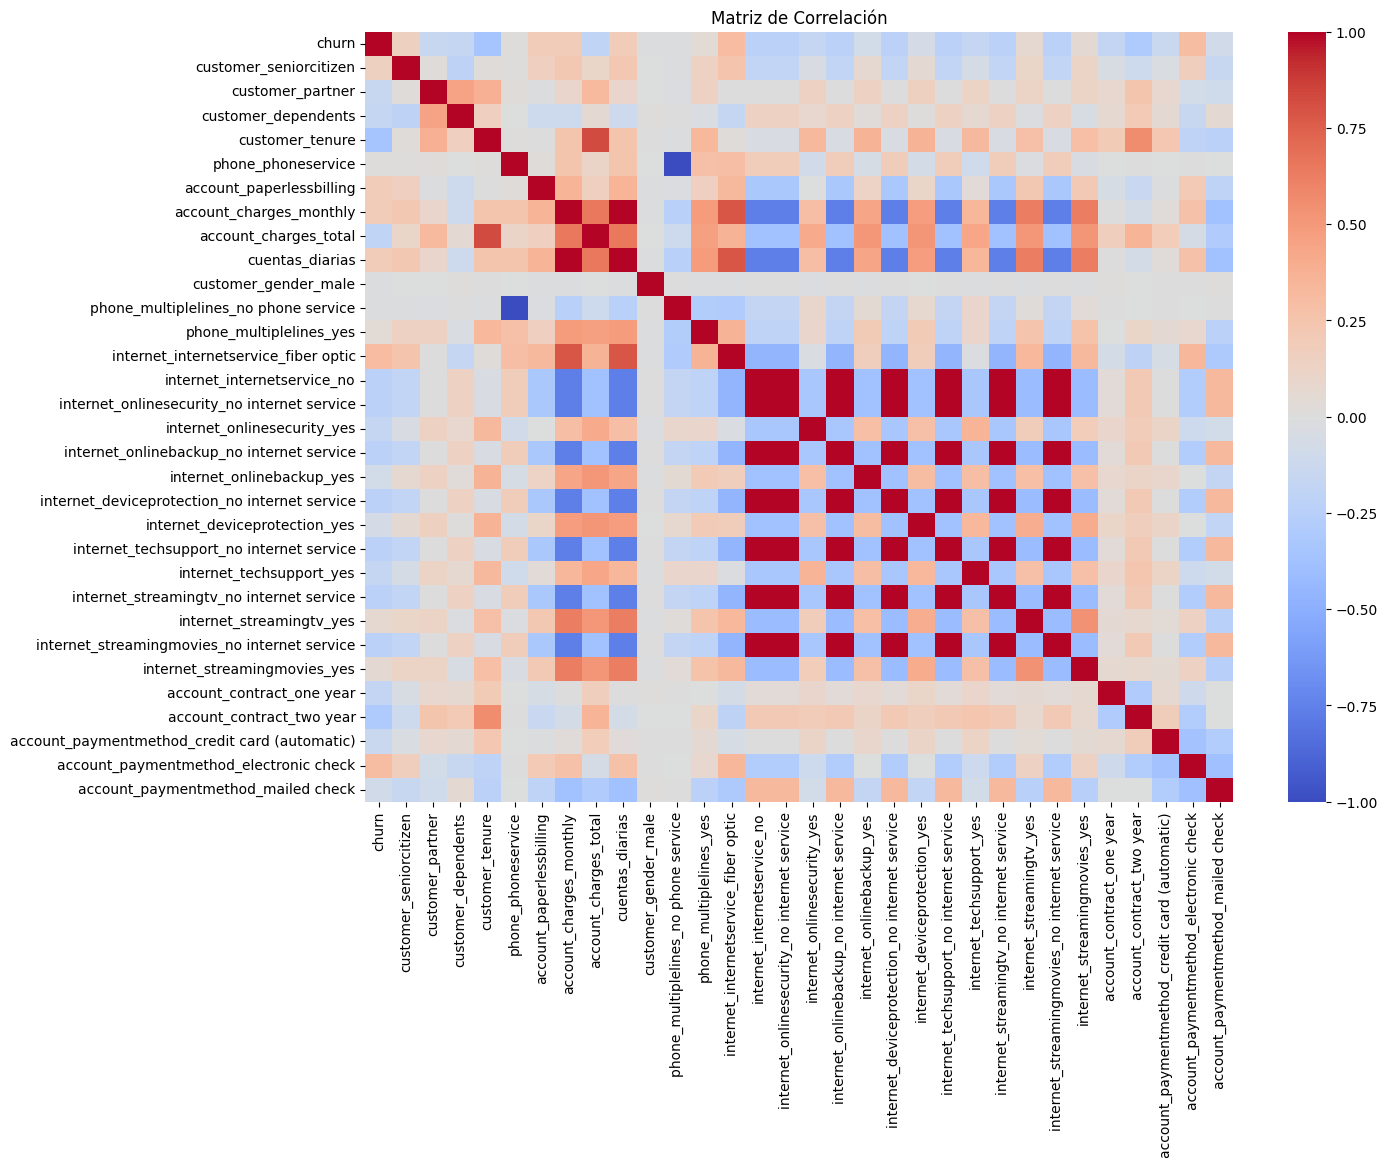

In [20]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de Correlación")
plt.show()

In [21]:
corr_churn = df_encoded.corr()['churn'].sort_values(ascending=False)

corr_churn

,churn
churn,1.000000
internet_internetservice_fiber optic,0.308020
account_paymentmethod_electronic check,0.301919
account_charges_monthly,0.193356
cuentas_diarias,0.193356
account_paperlessbilling,0.191825
customer_seniorcitizen,0.150889
internet_streamingtv_yes,0.063228
internet_streamingmovies_yes,0.061382
phone_multiplelines_yes,0.040102


In [22]:
top_corr = corr_churn[abs(corr_churn) > 0.2]

top_corr

,churn
churn,1.000000
internet_internetservice_fiber optic,0.308020
account_paymentmethod_electronic check,0.301919
internet_internetservice_no,-0.227890
internet_streamingtv_no internet service,-0.227890
internet_onlinesecurity_no internet service,-0.227890
internet_onlinebackup_no internet service,-0.227890
internet_deviceprotection_no internet service,-0.227890
internet_streamingmovies_no internet service,-0.227890
internet_techsupport_no internet service,-0.227890


In [23]:
selected_features = top_corr.index

corr_selected = df_encoded[selected_features].corr()

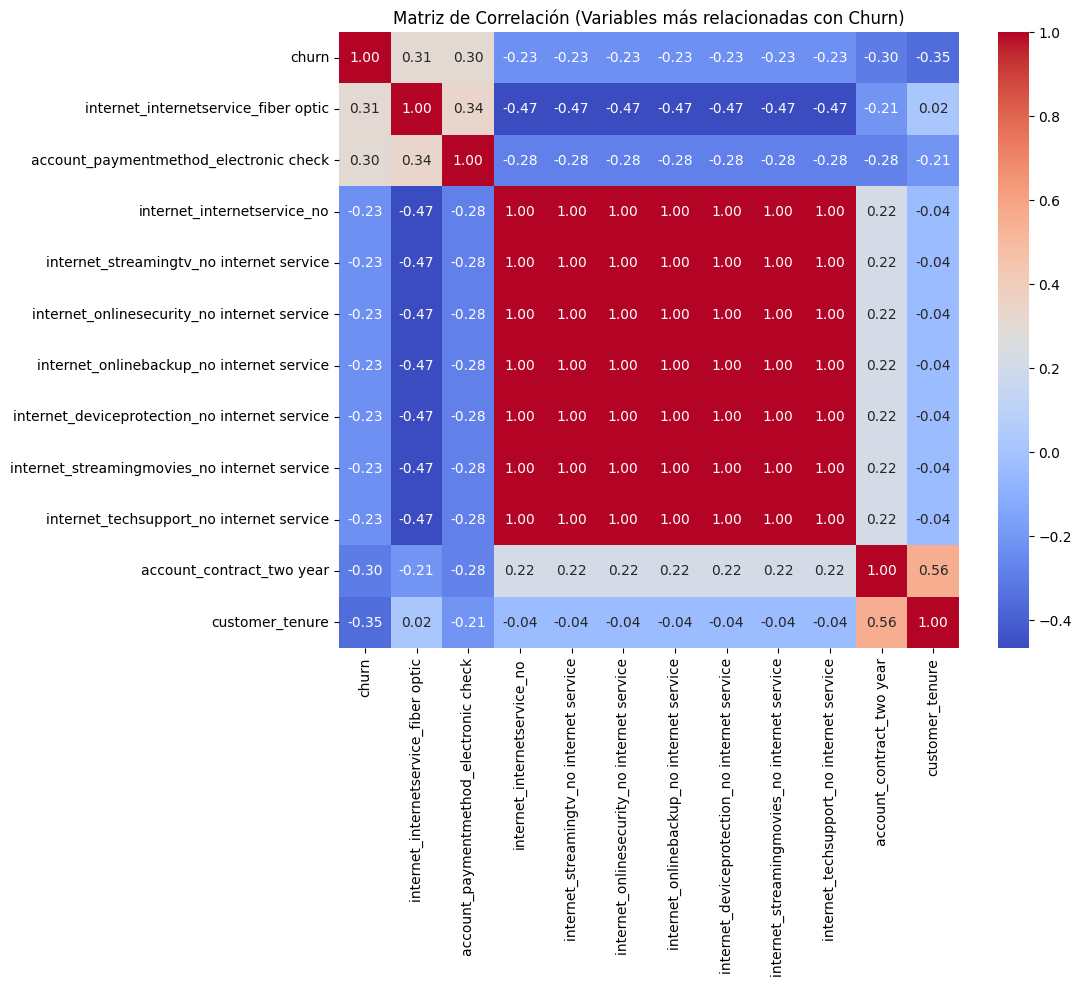

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_selected,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación (Variables más relacionadas con Churn)")
plt.show()

### **Análisis Dirigido**

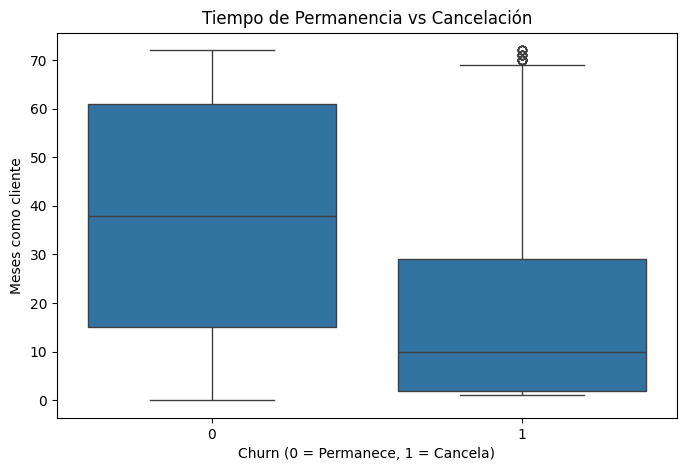

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='customer_tenure', data=df_encoded)

plt.title('Tiempo de Permanencia vs Cancelación')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Meses como cliente')

plt.show()

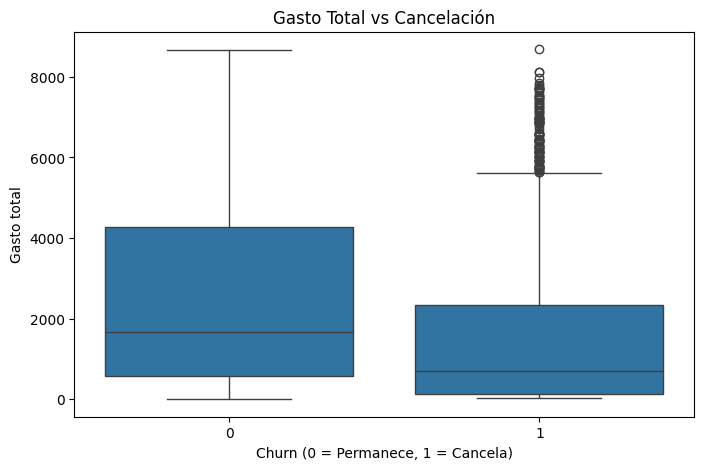

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x='churn', y='account_charges_total', data=df_encoded)

plt.title('Gasto Total vs Cancelación')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Gasto total')

plt.show()

## **🤖 Modelado Predictivo**

### **Separación de Datos**

In [27]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5634, 31)
Datos de prueba: (1409, 31)


In [30]:
print("Proporción de churn en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción de churn en prueba:")
print(y_test.value_counts(normalize=True))

Proporción de churn en entrenamiento:
churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Proporción de churn en prueba:
churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


### **Creación de Modelos**

**Modelo 1 — Regresión Logística**

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred_log = log_model.predict(X_test_scaled)

**Modelo 2 — Random Forest**

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
y_pred_rf = rf_model.predict(X_test)

### Evaluación de los Modelos

Para evaluar el desempeño de los modelos de clasificación se utilizaron las métricas de exactitud (accuracy), precisión, recall, F1-score y matriz de confusión.

Resultados del modelo de Regresión Logística

In [38]:
print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_log))

Accuracy Regresión Logística: 0.7927608232789212

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

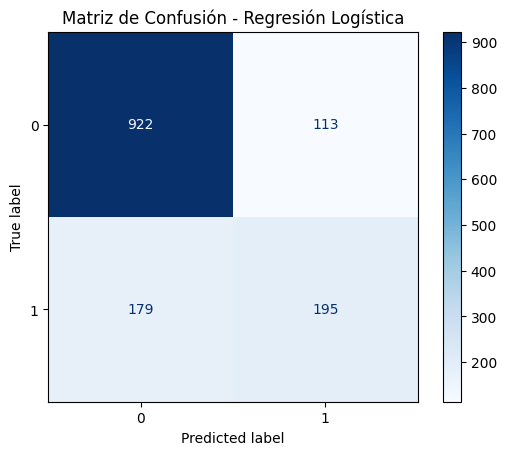

In [40]:
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot(cmap="Blues")

plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

Este modelo tiene un buen desempeño en la identificación de la clase 0, con valores altos de precisión y recall (0.84 y 0.89).

Su desempeño en la clase 1 es más moderado, el modelo presenta una precisión de aproximadamente 0.63 y un recall cercano a 0.52, lo que significa que, aunque una parte importante de las predicciones positivas son correctas, no todos los casos reales de esta clase son detectados por el modelo.

La matriz de confusión confirma este comportamiento.

Resultados del modelo Random Forest

In [41]:
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.7856635911994322

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



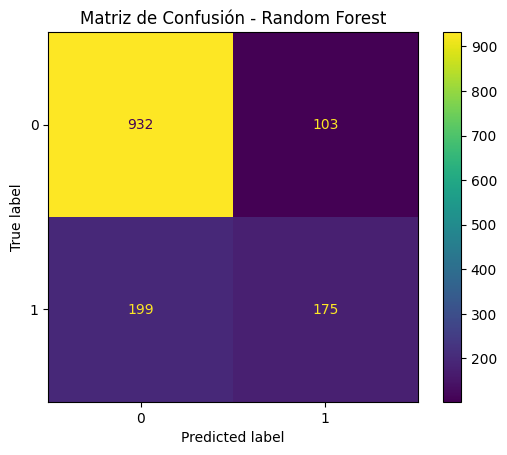

In [42]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Matriz de Confusión - Random Forest")
plt.show()

El modelo muestra un buen desempeño para la clase 0, identifica correctamente la mayoria de estos casos. Esto se evidencia en el alto recall de 0.90 y en los 932 verdaderos negativos.

Sin embargo, el modelo presenta dificultades para detectar la clase 1, con un recall de 0.47, lo que indica que una importante cantidad de casos positivos no son detectados correctamente.

**Comparación entre modelos**

---

| Métrica          | Random Forest | Regresión Logística |
| ---------------- | ------------- | ------------------- |
| Accuracy         | 0.786         | **0.792**           |
| Recall clase 1   | 0.47          | **0.52**            |
| F1-score clase 1 | 0.54          | **0.57**            |

---

Ambos modelos presentan un desempeño similar. Sin embargo, la regresión logística obtiene un rendimiento ligeramente superior, ya que presenta:

*   Mayor exactitud
*   Mejor recall para la clase minoritaria
*   Mejor F1-score

Esto indica que la regresión logística logra identificar más correctamente los casos positivos.

**Análisis de Overfitting y Underfitting**

Con respecto al overfitting, no se observa evidencia clara de su existencia en los modelos ya que el rendimiento de los modelos en el conjunto de prueba no es excesivamente alto y los resultados parecen razonables.

Para el underfitting se puede observar de manera parcial, especialmente en la capacidad de detectar la clase 1. Se evidencia en el recall relativamente bajo y la presencia de varios falsos negativos.

### Análisis de la Importancia de las Variables

**Importancia de variables en Regresión Logística**

En el modelo de Regresión Logística la importancia de las variables es analisado a través de los coeficientes del modelo.

Cada coeficiente indica cómo influye una variable en la probabilidad de que ocurra la cancelación.

*   Coeficientes positivos: aumentan la probabilidad de cancelación.
*   Coeficientes negativos: reducen la probabilidad de cancelación.
*   Valores absolutos más altos: indican mayor impacto en la predicción.


Por lo tanto, las variables con coeficientes de mayor magnitud son las que tienen mayor influencia en el resultado del modelo. Este análisis permite comprender qué factores están más relacionados con la cancelación y cómo contribuyen a la decisión del modelo.


In [43]:
# Obtener coeficientes del modelo
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_model.coef_[0]
})

# Ordenar por importancia (valor absoluto)
coeficientes["Importancia"] = coeficientes["Coeficiente"].abs()
coeficientes = coeficientes.sort_values(by="Importancia", ascending=False)

# Mostrar las variables más importantes
print(coeficientes.head(10))

                                  Variable  Coeficiente  Importancia
3                          customer_tenure    -1.418773     1.418773
7                    account_charges_total     0.689606     0.689606
12    internet_internetservice_fiber optic     0.611787     0.611787
27               account_contract_two year    -0.581946     0.581946
8                          cuentas_diarias    -0.315089     0.315089
6                  account_charges_monthly    -0.315089     0.315089
26               account_contract_one year    -0.280022     0.280022
23                internet_streamingtv_yes     0.211228     0.211228
11                 phone_multiplelines_yes     0.201903     0.201903
29  account_paymentmethod_electronic check     0.190906     0.190906


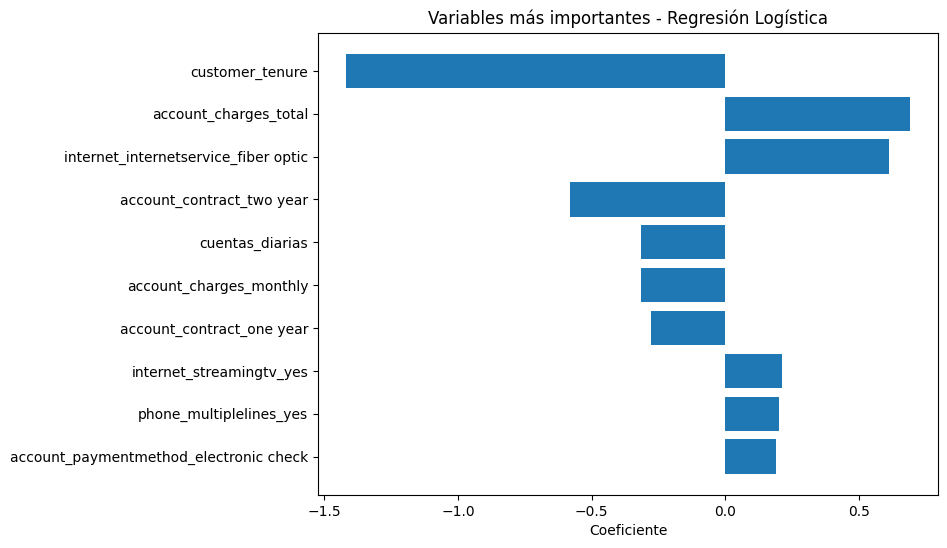

In [44]:
top_variables = coeficientes.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_variables["Variable"], top_variables["Coeficiente"])
plt.title("Variables más importantes - Regresión Logística")
plt.xlabel("Coeficiente")
plt.gca().invert_yaxis()
plt.show()

**Importancia de variables en Random Forest**

Para este modelo, la importancia de las variables se calcula mediante la reducción de la impureza durante la construcción de los árboles de decisión.

Cada vez que una variable se utiliza para dividir un nodo en un árbol, el modelo mide cuánto mejora la pureza de las clases. Las variables que contribuyen más a reducir la impureza son consideradas más importantes.

El modelo asigna a cada variable un valor de importancia relativa, que representa su contribución al proceso de clasificación.

Las variables con mayor puntuación de importancia son aquellas que tienen mayor influencia en la predicción de la cancelación, ya que son utilizadas con mayor frecuencia o generan divisiones más informativas dentro de los árboles del bosque.

In [45]:
# Obtener importancia de variables
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_model.feature_importances_
})

# Ordenar por importancia
importancias = importancias.sort_values(by="Importancia", ascending=False)

# Mostrar las variables más importantes
print(importancias.head(10))

                                  Variable  Importancia
7                    account_charges_total     0.167309
3                          customer_tenure     0.159065
6                  account_charges_monthly     0.130267
8                          cuentas_diarias     0.126258
12    internet_internetservice_fiber optic     0.034147
29  account_paymentmethod_electronic check     0.034052
27               account_contract_two year     0.032848
9                     customer_gender_male     0.024755
5                 account_paperlessbilling     0.023829
21                internet_techsupport_yes     0.022713


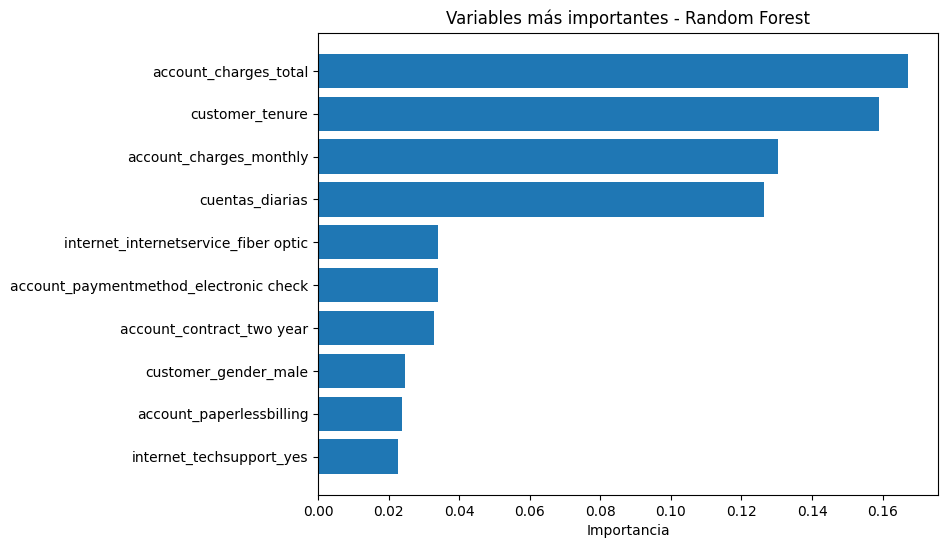

In [46]:
top_importancias = importancias.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_importancias["Variable"], top_importancias["Importancia"])
plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.show()

### **CONCLUSIÓN**

En este desafío se desarrollaron modelos de Machine Learning con el objetivo de predecir la cancelación de clientes a partir de diferentes variables del conjunto de datos. Para ello se implementaron modelos de Regresión Logística y Random Forest, los cuales fueron evaluados utilizando métricas como exactitud, precisión, recall, F1-score y matriz de confusión.

Los resultados obtenidos muestran que ambos modelos presentan un desempeño similar, con una exactitud cercana al 79 %. Sin embargo, el modelo de regresión logística mostró un rendimiento ligeramente superior en la detección de la clase asociada a la cancelación, logrando un mejor equilibrio entre precisión y recall.

El análisis de importancia de variables permitió identificar los factores más relevantes en la predicción del churn. En ambos modelos se observó que variables relacionadas con los costos del servicio y el tiempo de permanencia del cliente tienen un impacto significativo en la probabilidad de cancelación.

Entre las variables más influyentes destacan:

*  account_charges_total

*  customer_tenure

*  account_charges_monthly

*  cuentas_diarias

*  internet_internetservice_fiber optic

Estas variables indican que el gasto total del cliente, el tiempo que permanece en la empresa y los costos mensuales del servicio son factores clave que influyen en la decisión de cancelar. Además, características del servicio contratado, como el tipo de conexión a internet, también tienen un impacto importante en el comportamiento del cliente.


A partir de estos resultados, se pueden proponer diversas estrategias de retención de clientes, tales como:

*  Implementar programas de fidelización para a clientes con menor tiempo de permanencia

*  Ofrecer planes más competitivos o descuentos para clientes con altos cargos mensuales

*  Mejorar la experiencia del servicio para clientes con internet de fibra óptica, que aparece como una variable relevante en el análisis

*  Realizar monitoreo preventivo de clientes con altos cargos acumulados, ya que podrían presentar mayor riesgo de cancelación


En conclusión, los modelos desarrollados permiten identificar patrones importantes en el comportamiento de los clientes y anticipar posibles cancelaciones, lo que puede ayudar a las empresas a implementar estrategias proactivas para mejorar la retención de clientes y reducir la pérdida de ingresos.